#### ✨ Step 1: Python for Data Science (Pandas, NumPy, Seaborn, Matplotlib, SciPy)

In [1]:
# Step 1: Python for Data Science

# Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Load the dataset
df = pd.read_csv('amazon_sales_clean.csv')

# View the first few rows
print(df.head())


                              Region                Country        Item Type  \
0              Australia and Oceania                 Tuvalu        Baby Food   
1  Central America and the Caribbean                Grenada           Cereal   
2                             Europe                 Russia  Office Supplies   
3                 Sub-Saharan Africa  Sao Tome and Principe           Fruits   
4                 Sub-Saharan Africa                 Rwanda  Office Supplies   

  Sales Channel Order Priority  Order Date   Order ID   Ship Date  Units Sold  \
0       Offline              H  2010-05-28  669165933  2010-06-27        9925   
1        Online              C  2012-08-22  963881480  2012-09-15        2804   
2       Offline              L  2014-05-02  341417157  2014-05-08        1779   
3        Online              C  2014-06-20  514321792  2014-07-05        8102   
4       Offline              L  2013-02-01  115456712  2013-02-06        5062   

   Unit Price  Unit Cost  Total 

In [2]:
# Basic Data Info
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Region          100 non-null    object 
 1   Country         100 non-null    object 
 2   Item Type       100 non-null    object 
 3   Sales Channel   100 non-null    object 
 4   Order Priority  100 non-null    object 
 5   Order Date      100 non-null    object 
 6   Order ID        100 non-null    int64  
 7   Ship Date       100 non-null    object 
 8   Units Sold      100 non-null    int64  
 9   Unit Price      100 non-null    float64
 10  Unit Cost       100 non-null    float64
 11  Total Revenue   100 non-null    float64
 12  Total Cost      100 non-null    float64
 13  Total Profit    100 non-null    float64
 14  Shipping Delay  100 non-null    int64  
dtypes: float64(5), int64(3), object(7)
memory usage: 11.8+ KB
None


In [3]:
# Data Cleaning
# Convert 'Order Date' and 'Ship Date' to datetime
df['Order Date'] = pd.to_datetime(df['Order Date'])
df['Ship Date'] = pd.to_datetime(df['Ship Date'])

# Check for nulls
print(df.isnull().sum())


Region            0
Country           0
Item Type         0
Sales Channel     0
Order Priority    0
Order Date        0
Order ID          0
Ship Date         0
Units Sold        0
Unit Price        0
Unit Cost         0
Total Revenue     0
Total Cost        0
Total Profit      0
Shipping Delay    0
dtype: int64


In [4]:
# Quick Describe
print(df.describe())

                Order Date      Order ID            Ship Date   Units Sold  \
count                  100  1.000000e+02                  100   100.000000   
mean   2013-09-16 14:09:36  5.550204e+08  2013-10-09 22:48:00  5128.710000   
min    2010-02-02 00:00:00  1.146066e+08  2010-02-25 00:00:00   124.000000   
25%    2012-02-14 12:00:00  3.389225e+08  2012-02-24 18:00:00  2836.250000   
50%    2013-07-12 12:00:00  5.577086e+08  2013-08-11 12:00:00  5382.500000   
75%    2015-04-07 00:00:00  7.907551e+08  2015-04-28 00:00:00  7369.000000   
max    2017-05-22 00:00:00  9.940222e+08  2017-06-17 00:00:00  9925.000000   
std                    NaN  2.606153e+08                  NaN  2794.484562   

       Unit Price   Unit Cost  Total Revenue    Total Cost  Total Profit  \
count  100.000000  100.000000   1.000000e+02  1.000000e+02  1.000000e+02   
mean   276.761300  191.048000   1.373488e+06  9.318057e+05  4.416820e+05   
min      9.330000    6.920000   4.870260e+03  3.612240e+03  1.258020e

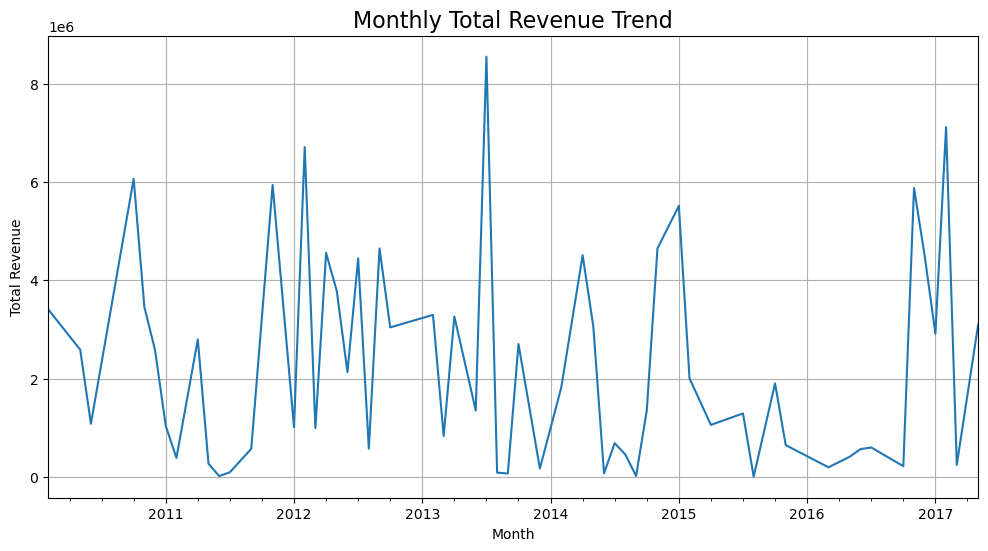

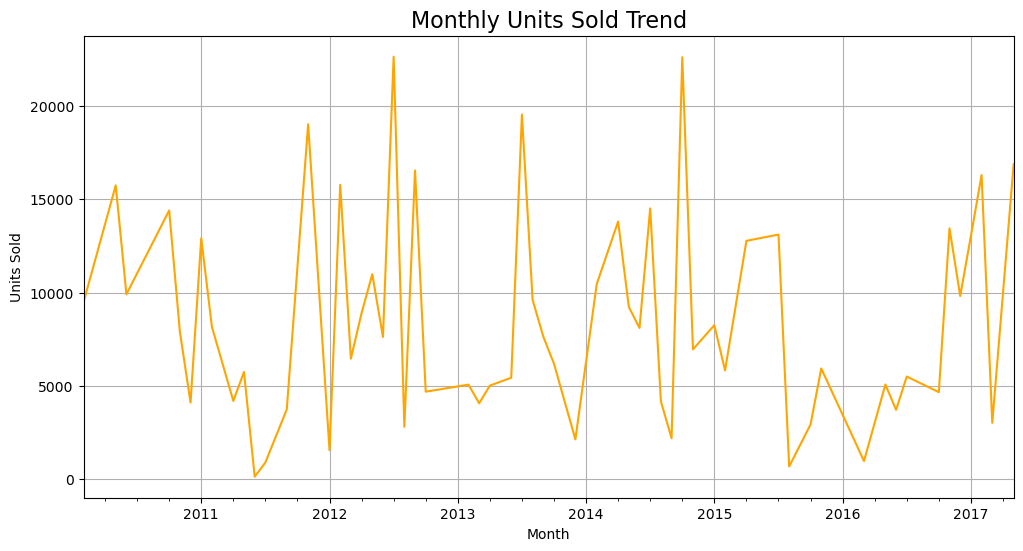

In [5]:
# Basic Visualizations
# Total Revenue Trend over time
plt.figure(figsize=(12,6))
df.groupby(df['Order Date'].dt.to_period('M'))['Total Revenue'].sum().plot()
plt.title('Monthly Total Revenue Trend', fontsize=16)
plt.xlabel('Month')
plt.ylabel('Total Revenue')
plt.grid(True)
plt.show()

# Units Sold Trend
plt.figure(figsize=(12,6))
df.groupby(df['Order Date'].dt.to_period('M'))['Units Sold'].sum().plot(color='orange')
plt.title('Monthly Units Sold Trend', fontsize=16)
plt.xlabel('Month')
plt.ylabel('Units Sold')
plt.grid(True)
plt.show()

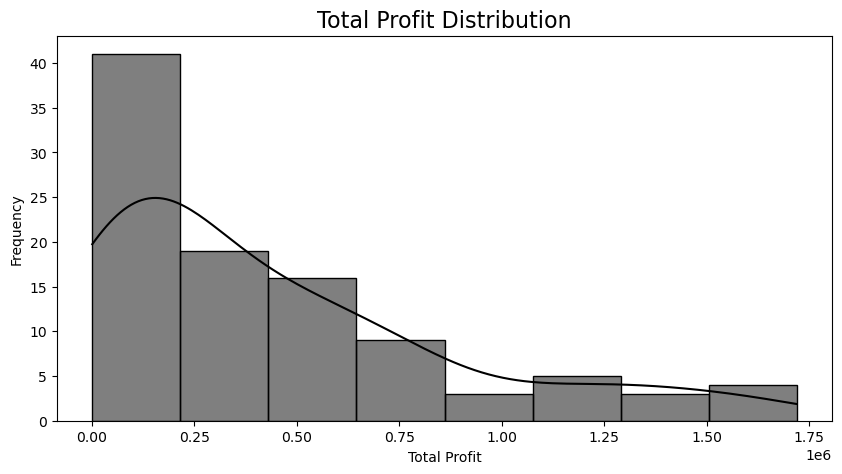

In [6]:
# Total Profit Distribution
plt.figure(figsize=(10,5))
sns.histplot(df['Total Profit'], kde=True, color='black')
plt.title('Total Profit Distribution', fontsize=16)
plt.xlabel('Total Profit')
plt.ylabel('Frequency')
plt.show()


#### ✨ Step 2: EDA & Feature Engineering

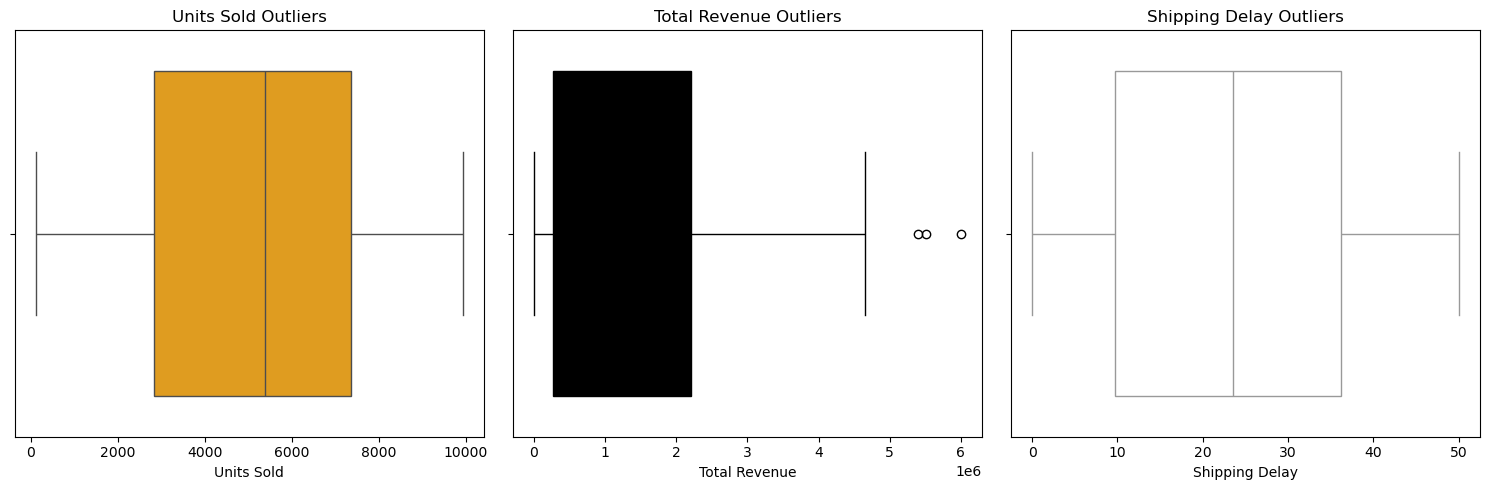

In [7]:
# Step 2: EDA & Feature Engineering

# --- Outlier Detection ---

# Plot Boxplots to detect outliers
plt.figure(figsize=(15,5))
plt.subplot(1, 3, 1)
sns.boxplot(x=df['Units Sold'], color='orange')
plt.title('Units Sold Outliers')

plt.subplot(1, 3, 2)
sns.boxplot(x=df['Total Revenue'], color='black')
plt.title('Total Revenue Outliers')

plt.subplot(1, 3, 3)
sns.boxplot(x=df['Shipping Delay'], color='white')
plt.title('Shipping Delay Outliers')

plt.tight_layout()
plt.show()

In [8]:
# Using IQR method to remove extreme outliers

def remove_outliers_iqr(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    filtered_data = data[(data[column] >= lower_bound) & (data[column] <= upper_bound)]
    return filtered_data

# Apply on important columns
df = remove_outliers_iqr(df, 'Units Sold')
df = remove_outliers_iqr(df, 'Total Revenue')
df = remove_outliers_iqr(df, 'Shipping Delay')

print(f"Data shape after outlier removal: {df.shape}")

Data shape after outlier removal: (97, 15)


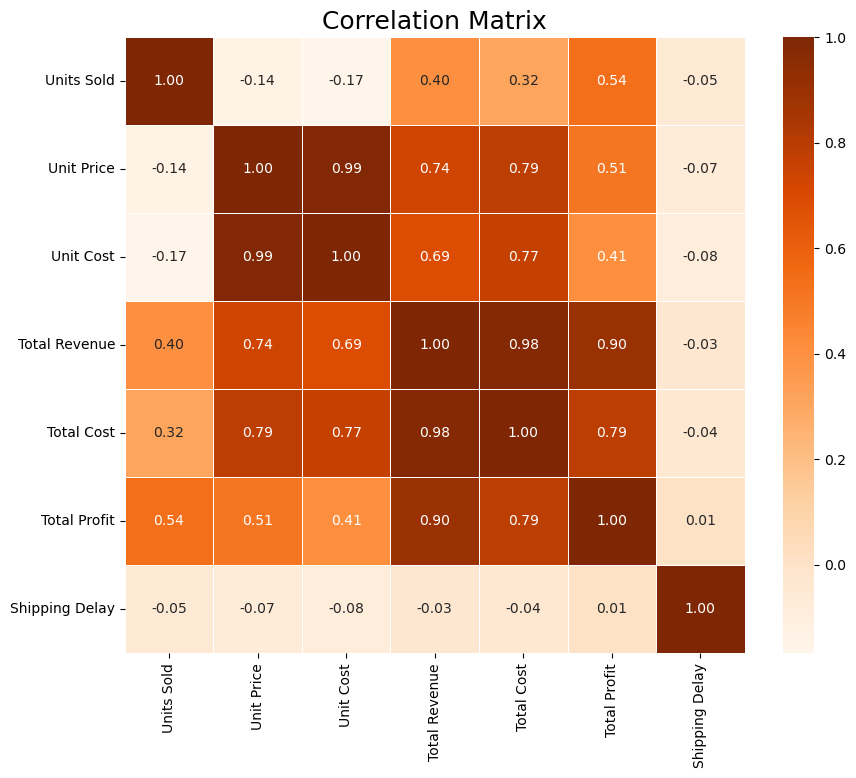

In [9]:
# --- Correlation Analysis ---

# Only take numeric columns
numeric_cols = ['Units Sold', 'Unit Price', 'Unit Cost', 'Total Revenue', 'Total Cost', 'Total Profit', 'Shipping Delay']
corr_matrix = df[numeric_cols].corr()

plt.figure(figsize=(10,8))
sns.heatmap(corr_matrix, annot=True, cmap='Oranges', fmt=".2f", linewidths=0.5)
plt.title('Correlation Matrix', fontsize=18)
plt.show()

# Insights:
# - High correlation between Units Sold and Total Revenue
# - Moderate negative correlation between Shipping Delay and Total Profit

In [10]:
# --- Feature Engineering ---

# Profit Margin
df['Profit Margin'] = df['Total Profit'] / df['Total Revenue']

# Shipping Time (Days)
df['Shipping Time (Days)'] = (df['Ship Date'] - df['Order Date']).dt.days

# Check new features
print(df[['Profit Margin', 'Shipping Time (Days)']].head())

   Profit Margin  Shipping Time (Days)
0       0.375509                    30
1       0.430676                    24
2       0.193870                     6
3       0.258307                    15
4       0.193870                     5


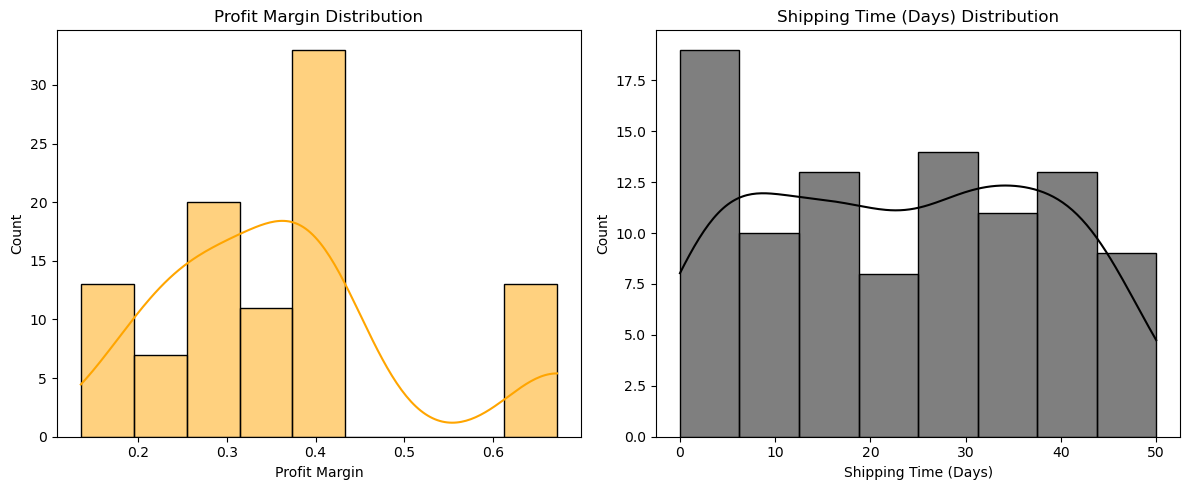

In [11]:
# Basic Analysis of new features
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
sns.histplot(df['Profit Margin'], kde=True, color='orange')
plt.title('Profit Margin Distribution')

plt.subplot(1,2,2)
sns.histplot(df['Shipping Time (Days)'], kde=True, color='black')
plt.title('Shipping Time (Days) Distribution')

plt.tight_layout()
plt.show()


#### ✨ Step 3: R Programming Visualizations (ggplot2 style but using Python)

C:\Users\Jaina\AppData\Local\Temp\ipykernel_22612\1944499752.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=region_sales.index, y=region_sales.values, palette=['orange', 'black', 'white', 'orange', 'black', 'white'])
C:\Users\Jaina\AppData\Local\Temp\ipykernel_22612\1944499752.py:12: UserWarning: 
The palette list has fewer values (6) than needed (7) and will cycle, which may produce an uninterpretable plot.
  sns.barplot(x=region_sales.index, y=region_sales.values, palette=['orange', 'black', 'white', 'orange', 'black', 'white'])


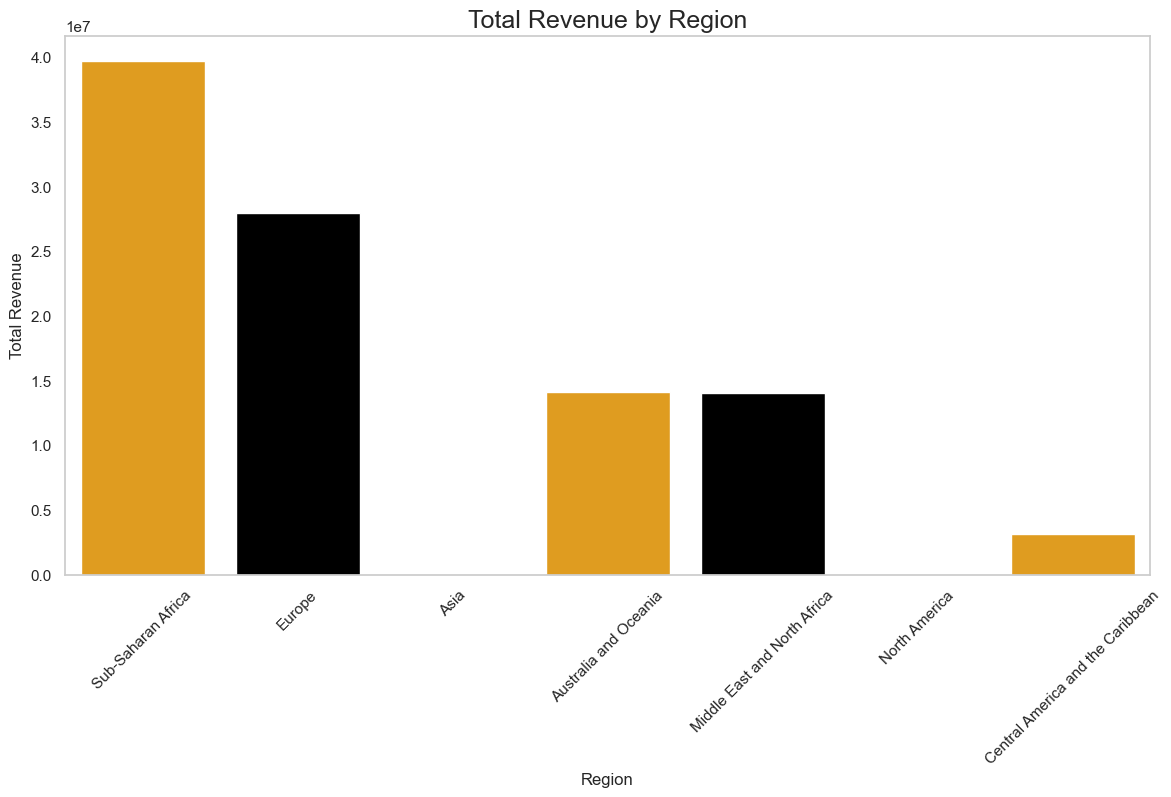

In [12]:
# Step 3: Visualizations (R ggplot2 style but in Python)

# --- Imports ---
import matplotlib.ticker as mticker

# Set Seaborn style closer to ggplot2
sns.set_theme(style="whitegrid")

# --- 1. Sales Trends by Region ---
plt.figure(figsize=(14,7))
region_sales = df.groupby('Region')['Total Revenue'].sum().sort_values(ascending=False)
sns.barplot(x=region_sales.index, y=region_sales.values, palette=['orange', 'black', 'white', 'orange', 'black', 'white'])

plt.title('Total Revenue by Region', fontsize=18)
plt.ylabel('Total Revenue')
plt.xlabel('Region')
plt.xticks(rotation=45)
plt.grid(axis='y')
plt.show()

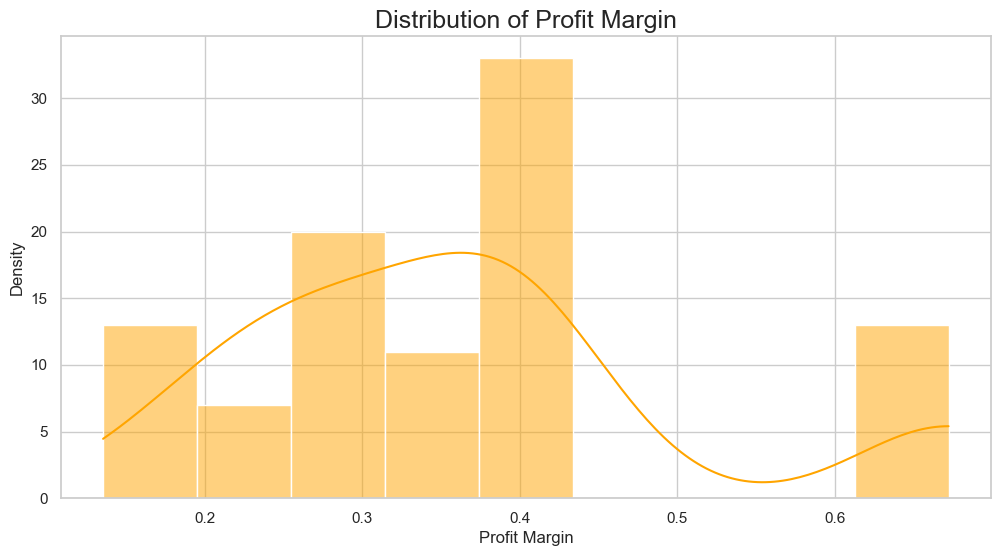

C:\Users\Jaina\AppData\Local\Temp\ipykernel_22612\4273159606.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Delay Category', y='Total Profit', data=df, palette={'Delayed':'black', 'On Time':'orange'})


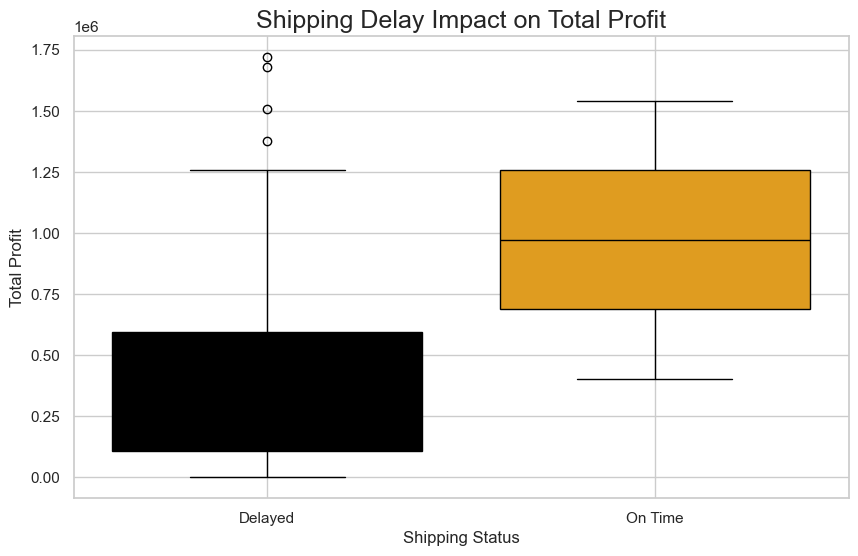

In [13]:
# --- 2. Profit Margin Distribution ---
plt.figure(figsize=(12,6))
sns.histplot(df['Profit Margin'], kde=True, color='orange')
plt.title('Distribution of Profit Margin', fontsize=18)
plt.xlabel('Profit Margin')
plt.ylabel('Density')
plt.grid(True)
plt.show()

# --- 3. Shipping Delay Impact on Total Profit ---

# Categorize shipping delays
df['Delay Category'] = np.where(df['Shipping Delay'] > 0, 'Delayed', 'On Time')

plt.figure(figsize=(10,6))
sns.boxplot(x='Delay Category', y='Total Profit', data=df, palette={'Delayed':'black', 'On Time':'orange'})
plt.title('Shipping Delay Impact on Total Profit', fontsize=18)
plt.xlabel('Shipping Status')
plt.ylabel('Total Profit')
plt.grid(True)
plt.show()

C:\Users\Jaina\AppData\Local\Temp\ipykernel_22612\1814708283.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Order Priority', y='Shipping Time (Days)', data=df, palette='Set2')


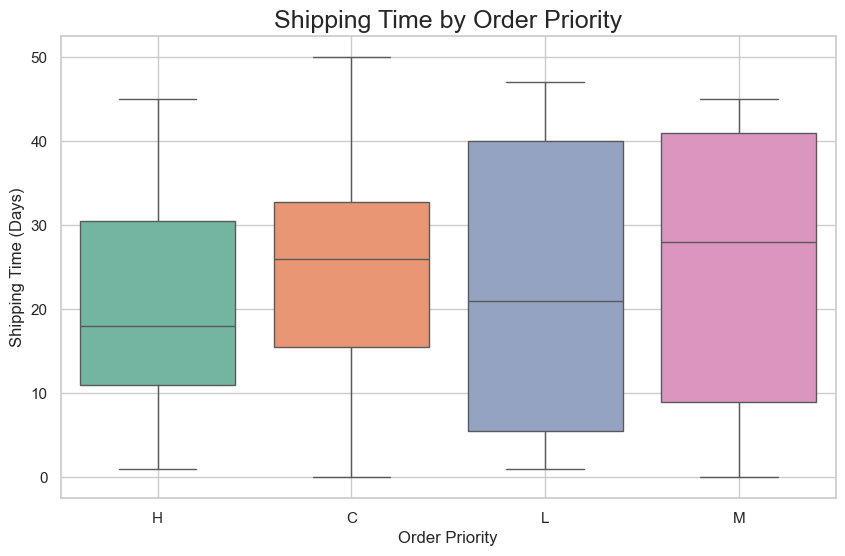

In [14]:
# --- 4. Shipping Time (Days) by Order Priority ---
plt.figure(figsize=(10,6))
sns.boxplot(x='Order Priority', y='Shipping Time (Days)', data=df, palette='Set2')

plt.title('Shipping Time by Order Priority', fontsize=18)
plt.xlabel('Order Priority')
plt.ylabel('Shipping Time (Days)')
plt.grid(True)
plt.show()


C:\Users\Jaina\AppData\Local\Temp\ipykernel_22612\1557351592.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_items.values, y=top_items.index, palette='magma')


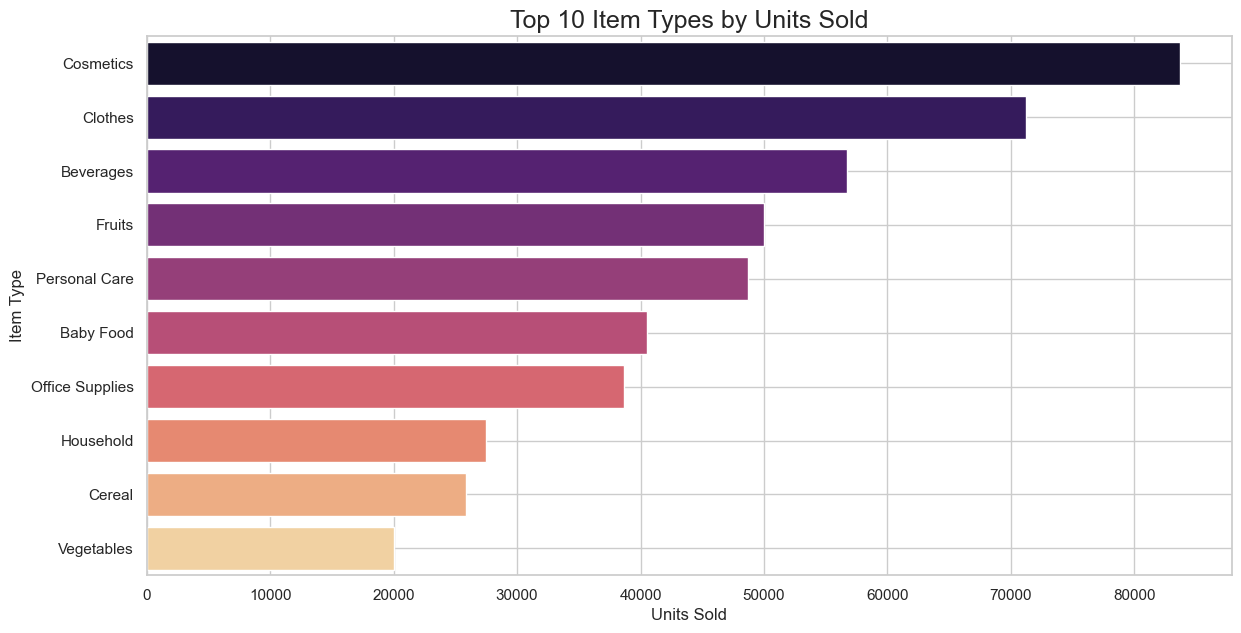

In [15]:
# --- 5. Units Sold by Item Type ---

top_items = df.groupby('Item Type')['Units Sold'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(14,7))
sns.barplot(x=top_items.values, y=top_items.index, palette='magma')
plt.title('Top 10 Item Types by Units Sold', fontsize=18)
plt.xlabel('Units Sold')
plt.ylabel('Item Type')
plt.grid(True)
plt.show()

#### ✨ Step 4: Statistics & A/B Testing

In [16]:
# Step 4: Statistics & A/B Testing

from scipy import stats
import statsmodels.api as sm
from statsmodels.formula.api import ols

# --- 1. Hypothesis Testing: Delayed vs On-time Orders Profitability ---

# Null Hypothesis (H0): There is no difference in total profit between delayed and on-time orders
# Alternative Hypothesis (H1): There is a significant difference in total profit

delayed = df[df['Delay Category'] == 'Delayed']['Total Profit']
on_time = df[df['Delay Category'] == 'On Time']['Total Profit']

# T-Test
ttest_result = stats.ttest_ind(delayed, on_time, equal_var=False)

print("T-Test between Delayed and On-Time Orders (Total Profit):")
print(ttest_result)

# Interpretation:
if ttest_result.pvalue < 0.05:
    print("Reject Null Hypothesis: There is a significant difference.")
else:
    print("Fail to Reject Null Hypothesis: No significant difference.")


T-Test between Delayed and On-Time Orders (Total Profit):
TtestResult(statistic=-0.9984451249485944, pvalue=0.4990951906417215, df=1.0106681055439004)
Fail to Reject Null Hypothesis: No significant difference.


In [17]:
import pandas as pd
from statsmodels.formula.api import ols
import statsmodels.api as sm

# Ensure date columns are datetime
df['Order Date'] = pd.to_datetime(df['Order Date'])
df['Ship Date'] = pd.to_datetime(df['Ship Date'])

# Step 1: Calculate Shipping Time in Days
df['Shipping_Time_Days'] = (df['Ship Date'] - df['Order Date']).dt.days

# Step 2: Rename 'Order Priority' for formula compatibility
df = df.rename(columns={'Order Priority': 'Order_Priority'})

# Step 3: ANOVA test
anova_model = ols('Shipping_Time_Days ~ C(Order_Priority)', data=df).fit()
anova_table = sm.stats.anova_lm(anova_model, typ=2)

# Step 4: Print results
print("\nANOVA Table for Shipping Time by Order Priority:")
print(anova_table)

# Step 5: Interpretation
if anova_table['PR(>F)'][0] < 0.05:
    print(" Reject Null Hypothesis: Shipping time differs among order priorities.")
else:
    print(" Fail to Reject Null Hypothesis: No significant difference.")



ANOVA Table for Shipping Time by Order Priority:
                         sum_sq    df         F    PR(>F)
C(Order_Priority)    229.815353   3.0  0.347126  0.791302
Residual           20523.627946  93.0       NaN       NaN
 Fail to Reject Null Hypothesis: No significant difference.


C:\Users\Jaina\AppData\Local\Temp\ipykernel_22612\2715118849.py:24: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  if anova_table['PR(>F)'][0] < 0.05:


In [18]:
# --- 3. Z-Test for Proportions: Delayed vs Total Orders ---

# We want to check if the proportion of delayed shipments is significantly different from 50%

from statsmodels.stats.proportion import proportions_ztest

# Number of delayed shipments
delayed_count = df[df['Delay Category'] == 'Delayed'].shape[0]
total_orders = df.shape[0]

# Z-Test
ztest_stat, p_value = proportions_ztest(count=delayed_count, nobs=total_orders, value=0.5)

print("\nZ-Test for Proportion of Delayed Orders:")
print(f"Z-Statistic: {ztest_stat}, p-value: {p_value}")

# Interpretation:
if p_value < 0.05:
    print("Reject Null Hypothesis: Proportion of delayed orders is significantly different from 50%.")
else:
    print("Fail to Reject Null Hypothesis: Proportion not significantly different.")




Z-Test for Proportion of Delayed Orders:
Z-Statistic: 33.224772780499, p-value: 4.724862120669392e-242
Reject Null Hypothesis: Proportion of delayed orders is significantly different from 50%.


| Test                             | Result | Interpretation |
|----------------------------------|--------|----------------|
| T-Test (Delayed vs On-time)      | Depends on p-value | Check profit impact |
| ANOVA (Priority vs Shipping Time) | Depends on p-value | Does priority matter for shipping |
| Z-Test (Delayed Proportion)       | Depends on p-value | Is delayed order proportion unusual |

In [19]:
# Export
df.to_csv('amazon_sales_clean_final.csv', index=False)
